## Ingrandimento di immagini


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

#from google.colab import drive
#drive.mount('/content/drive')#

## Ingrandimento di immagini

Applichiamo le tecniche di interpolazione di superfici al problema di ingrandire un'immagine digitale.

I dati sono i pixel dell'immagine data $Z\in {\mathbb R}^{n\times m}$
$$ z_{ij}, \ \ i=0,...,n-1,\ j=0,...,m-1 $$

Siccome non c'è un riferimento spaziale specifico, le ascisse e le ordinate dei pixel si definiscono come gli interi da $0$ a $n-1$ e da $0$ a $m-1$, rispettivamente.



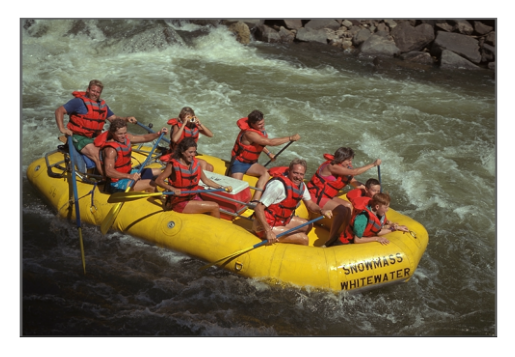

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

#/content/drive/MyDrive/Calcolo Numerico 2025-Informatica/Colab_lezione_pronti/Dati/kodim14.png
#path = "/content/drive/MyDrive/Calcolo Numerico 2025-Informatica/Colab_lezione_pronti/Dati/kodim14.png"

path = "Canotto.png"
img = Image.open(path)
plt.imshow(img)
plt.axis('off') # Nasconde gli assi
plt.show()

Trasformiamo l'oggetto immagine in un array con tre dimensioni (i canali RGB).

Dividiamo per 255, che è il massimo valore dei pixel nella scala rgb, per portare i pixel nell'intervallo $[0,1]$.

(350, 515, 3)


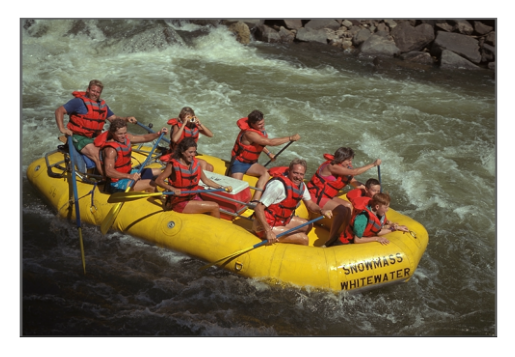

In [ ]:
Z = np.array(img,dtype=float)/255 #array di float normalizzati tra 0 e 1
print(Z.shape)
plt.imshow(Z)
plt.axis('off') # Nasconde gli assi
plt.show()

Selezioniamo un particolare dell'immagine, i cui indici di riga sono compresi tra 150 e 200, mentre quelli di colonna sono tra 250 e 300.

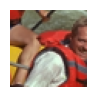

In [ ]:
dettaglio = Z[150:200,250:300,:]
fig = plt.figure(figsize = (1,1))
ax = fig.add_subplot(1,1,1)
ax.imshow(dettaglio)
ax.axis('off') # Nasconde gli assi
plt.show()

Per ingrandire l'immagine, si utilizzano le tecniche di interpolazione 2D applicate separatamente a ciascuno dei tre canali.

Per semplicità,

In [ ]:
def duplica(Z):
  n,m = Z.shape
  T = np.zeros((2*n-1,2*m-1))
  T[::2,::2] = Z[:,:]
  T[:,1::2] = T[:,:-1:2]
  T[1::2,:] = T[:-1:2,:]
  return T

def nearest_n(Z,N=1):
  T = Z.copy()
  for i in range(N):
    T = duplica(T)
  return T


def zoom_immagine(Z,N=1):
  (n,m,p) = Z.shape
  # Original grid coordinates for rows (height) and columns (width)
  y = np.linspace(0, n-1, n)
  x = np.linspace(0, m-1, m)

  n2 = 2**N*(n -1) + 1 # New height
  m2 = 2**N*(m -1) + 1 # New width

  Z2 = np.zeros((n2,m2,p))
  Zb = np.zeros((n2,m2,p))
  Zs = np.zeros((n2,m2,p))

  # Coordinate della griglia raffinata righe = verticale (y), colonne =  orizzontale (x)
  y2 = np.linspace(0, n-1, n2)
  x2 = np.linspace(0, m-1, m2)

  X2, Y2 = np.meshgrid(x2, y2)

  for i in range(p):
    #creazione della funzione di interpolazione dell'i-esimo canale
    bilin_interp = RegularGridInterpolator((y, x), Z[:,:,i], method="linear")
    cubic_spline_interp = RegularGridInterpolator((y, x), Z[:,:,i], method="cubic")

    Z2[:,:,i] = nearest_n(Z[:,:,i],N)
    # Valutazione della funzione interpolante nei punti della griglia raffinata
    Zb[:,:,i] = bilin_interp((Y2, X2))
    Zs[:,:,i] = cubic_spline_interp((Y2, X2))

  return Z2,Zb,Zs

In [ ]:
(Z2,Zb,Zs) = zoom_immagine(dettaglio,N=1)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.007014826916014574..1.0075441030697874].


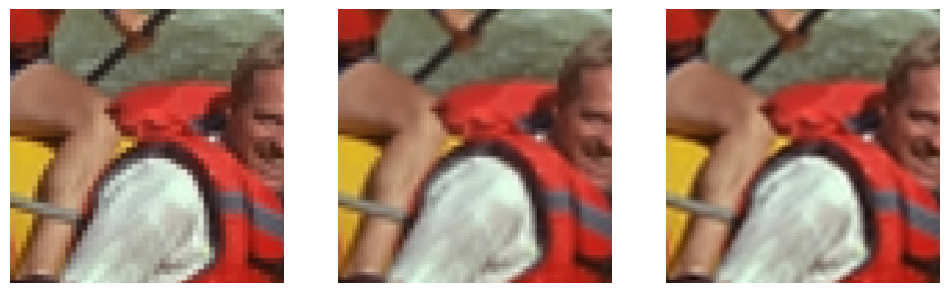

In [ ]:

fig = plt.figure(figsize = (12,12))
ax1 = fig.add_subplot(1,3,1)
ax1.imshow(Z2)
ax1.axis('off')
ax2= fig.add_subplot(1,3,2)
ax2.matshow(Zb)
ax2.axis('off')
ax3= fig.add_subplot(1,3,3)
ax3.matshow(Zs)
ax3.axis('off')

plt.show()